# Credit Card Customer Churn Prediction

Predicting bank customer churn using an Artificial Neural Network (Keras/TensorFlow).

Dataset: `Churn_Modelling.csv` (10,000 rows, 14 columns) — loaded directly from a public GitHub-hosted CSV so this notebook runs end-to-end without needing Kaggle dataset mounts.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Load Dataset

Originally this used the Kaggle path `/kaggle/input/.../Churn_Modelling.csv`, which only works inside a Kaggle session. Replaced with a public raw GitHub URL so it works anywhere (local, Colab, GitHub Actions, etc.). The file is downloaded once and cached locally as `Churn_Modelling.csv`.

In [2]:
import os
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"
DATA_PATH = "Churn_Modelling.csv"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


## 3. Data Cleaning

In [9]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


## 4. Encoding Categorical Features

In [11]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True).astype(int)
df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0


## 5. Train/Test Split

In [12]:
X = df.drop(columns=['Exited'])
y = df['Exited']


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape


(8000, 11)

## 6. Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. Build the ANN

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(11, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile & Train

In [16]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])


In [17]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7219 - loss: 0.5674 - val_accuracy: 0.7987 - val_loss: 0.4696
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7961 - loss: 0.4614 - val_accuracy: 0.8094 - val_loss: 0.4396
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8047 - loss: 0.4429 - val_accuracy: 0.8194 - val_loss: 0.4272
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8111 - loss: 0.4306 - val_accuracy: 0.8238 - val_loss: 0.4175
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8216 - loss: 0.4183 - val_accuracy: 0.8294 - val_loss: 0.4085
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8269 - loss: 0.4058 - val_accuracy: 0.8356 - val_loss: 0.3982
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8334 - loss: 0.3925 - val_accuracy: 0.8406 - val_loss: 0.3865
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8441 - loss: 0.3789 - val_accu

## 9. Inspect Learned Weights

In [18]:
# Layer 1: 11 inputs * 11 units (weights) + 11 (bias) = 132 trainable params
model.layers[0].get_weights()


[array([[-3.08539480e-01,  1.93914503e-01, -2.31194845e-03,
         -1.05866753e-01,  3.20050097e-03, -4.08390015e-01,
         -1.63195897e-02,  5.53674817e-01, -7.54423365e-02,
         -7.65693113e-02,  1.02623301e-02],
        [-8.03967118e-02, -8.72028291e-01,  4.09293801e-01,
          7.32533514e-01, -6.23667002e-01, -4.89851087e-01,
          6.54321730e-01, -1.04673900e-01,  4.71528143e-01,
          1.28011394e+00,  4.61191952e-01],
        [-1.67158917e-01, -1.91903971e-02, -6.29384741e-02,
         -1.29260376e-01,  1.01633035e-01, -1.00735977e-01,
          1.09446891e-01, -9.61886067e-03,  1.97497100e-01,
         -4.20020223e-02,  8.29428956e-02],
        [ 1.27787673e+00, -1.32736121e-03,  6.00576758e-01,
          1.52438790e-01,  3.03930312e-01, -5.31831086e-01,
         -9.62673053e-02, -1.58461079e-01, -1.72676414e-01,
         -1.71283796e-01, -4.59632963e-01],
        [-6.10373430e-02, -1.86759885e-02,  1.16341925e+00,
          1.11779106e+00, -2.88306922e-01, -

In [19]:
# Output layer: 11 * 1 (weights) + 1 (bias) = 12 trainable params
model.layers[2].get_weights()


[array([[-0.53174037],
        [ 0.88224274],
        [ 0.8120278 ],
        [-0.40809408],
        [-0.58325535],
        [-1.069725  ],
        [ 0.69449365],
        [-0.6896975 ],
        [-0.47867495],
        [ 0.8541457 ],
        [ 0.72063994]], dtype=float32),
 array([-0.18360093], dtype=float32)]

## 10. Predictions & Accuracy

In [20]:
y_log = model.predict(X_test_scaled)
# Sigmoid output is a probability; threshold at 0.5 to get class labels
y_pred = np.where(y_log > 0.5, 1, 0)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)


0.861

## 11. Training Curves

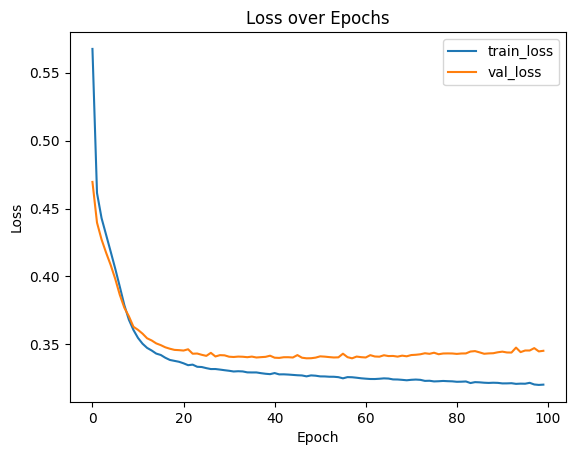

In [22]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()


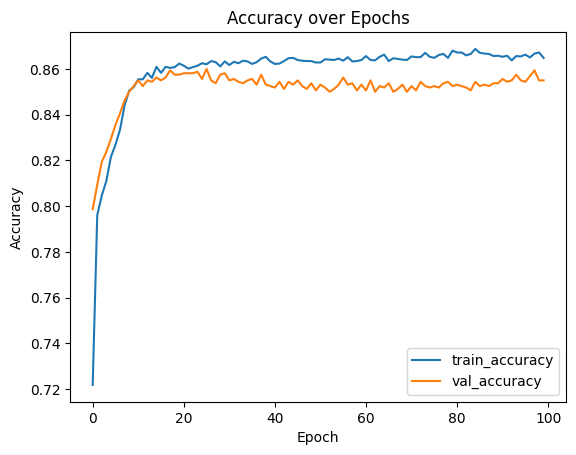

In [23]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()
